# Component: Glaciers

This notebook calibrates, validates, and projects the glacier component of GMSL rise. Key features:
- Linear Bayesian level-space fit on GlaMBIE global (2000–2023), with quadratic comparison
- BIC model selection confirms linear model is preferred
- Volume cap at 0.32 m SLE is considered, but the results never reach the cap (Farinotti et al. 2019)

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

sys.path.insert(0, '.')
from slr_data_readers import read_glambie_global, read_berkeley_earth
from bayesian_models import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, check_convergence,
)
from slr_projections import project_component_level_ensemble
from component_analysis import apply_sigma_taper
from component_projections import (
    apply_glacier_volume_cap, read_ipcc_component_nc, ipcc_extract,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)

from slr_forecast.config import BASELINE_YEAR, Z_90
H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

N_SAMPLES = 2000
V_GLACIER_TOTAL_M = 0.32  # Farinotti et al. 2019

## 1. Data Loading

In [2]:
# ── GlaMBIE glacier observations ──
df_glac = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')
glac_year = df_glac['decimal_year'].values
glac_rate = df_glac['mass_balance'].values              # m/yr SLE, positive = SLR
glac_rate_sigma = df_glac['mass_balance_sigma'].values

# Cumulative glacier SLR contribution (integrate annual rates)
glac_cumul = np.cumsum(glac_rate)                        # m SLE
glac_cumul_sigma = np.sqrt(np.cumsum(glac_rate_sigma**2))
bl_idx = np.argmin(np.abs(glac_year - BASELINE_YEAR))
glac_rebase = glac_cumul - glac_cumul[bl_idx]

# Rebased uncertainty: Var(Z - Z_bl) = Var(Z) + Var(Z_bl) - 2*Cov(Z, Z_bl).
# Since Z = sum(rate_k) and Z_bl is a partial sum of the same independent
# terms, Cov(Z, Z_bl) = Var(Z_bl) for points after the baseline (and
# Cov(Z, Z_bl) = Var(Z) for points before).  This gives
# sigma_rebased = sqrt(|sigma_cumul^2 - sigma_bl^2|).
glac_sigma = np.sqrt(np.abs(glac_cumul_sigma**2 - glac_cumul_sigma[bl_idx]**2))

# ── Berkeley Earth monthly temperature ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

# Annual temperature (for diagnostics and IPCC hindcast)
yr_int = np.floor(temp_time_monthly).astype(int)
unique_yrs = np.unique(yr_int)
T_annual = np.array([temp_monthly[yr_int == y].mean() for y in unique_yrs])
T_annual_years = unique_yrs + 0.5

print(f'GlaMBIE: {glac_year[0]:.0f}–{glac_year[-1]:.0f}, {len(glac_year)} points')
print(f'  Cumulative at {glac_year[-1]:.0f}: {glac_rebase[-1]*M_TO_MM:.1f} mm SLE')
print(f'  Mean rate: {np.mean(glac_rate)*M_TO_MM:.2f} mm/yr')

GlaMBIE: 2000–2024, 24 points
  Cumulative at 2024: 17.8 mm SLE
  Mean rate: 0.75 mm/yr


In [3]:
# ══════════════════════════════════════════════════════════════════
# REFIT SWITCH — set False to skip fitting and load saved results.
# If loading fails (no HDF5 file), fitting runs automatically.
# ══════════════════════════════════════════════════════════════════
REFIT = True

from component_io import save_glacier, load_component

if not REFIT:
    try:
        _loaded = load_component('glacier')
        glacier_proj = _loaded['projections']
        PROJ_YEARS = _loaded['proj_years']
        print(f'Loaded glacier from HDF5: {list(glacier_proj.keys())}')
    except (FileNotFoundError, KeyError) as e:
        print(f'Load failed ({e}) — falling back to REFIT=True')
        REFIT = True

## 2. Model Fitting

In [4]:
if REFIT:
    # ── Build design vectors ──
    OBS_WINDOW = (2000, 2023)
    mask = (glac_year >= OBS_WINDOW[0]) & (glac_year <= OBS_WINDOW[1])
    yrs_r = glac_year[mask]
    H_r = glac_rebase[mask].copy()
    sig_r = glac_sigma[mask].copy()

    design_r = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=yrs_r)

    # ── Priors ──
    PRIOR_SCALE_A = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.10/M_TO_MM)
    PRIOR_SCALE_B = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.20/M_TO_MM)
    PRIOR_C_MEAN = 0.0003
    PRIOR_C_SIGMA = 0.001
    PRIOR_SIGMA_EXTRA = 0.005
    PRIOR_H0_SIGMA = 0.005

    prior_kw = dict(prior_scale_a=PRIOR_SCALE_A, prior_scale_b=PRIOR_SCALE_B,
                    prior_c_mean=PRIOR_C_MEAN, prior_c_sigma=PRIOR_C_SIGMA,
                    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA, prior_H0_sigma=PRIOR_H0_SIGMA)

    # ── Quadratic fit ──
    result_quad = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_r,
        I2_obs=design_r['I2_obs'], I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=12000, n_walkers=64, n_burnin=4000, thin=2, seed=200, **prior_kw)

    # ── Linear fit (a=0) ──
    result_lin = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_r,
        I2_obs=np.zeros_like(design_r['I2_obs']),
        I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=300, **prior_kw)

    # ── Model selection (BIC) ──
    n = len(yrs_r)
    rss_q = np.sum(result_quad.residuals**2)
    rss_l = np.sum(result_lin.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    delta_bic = bic_l - bic_q

    a_med = np.median(result_quad.posterior_samples[:, 0]) * M_TO_MM
    b_lin_med = np.median(result_lin.posterior_samples[:, 1]) * M_TO_MM
    c_lin_med = np.median(result_lin.posterior_samples[:, 2]) * M_TO_MM

    print(f'Linear:    b = {b_lin_med:.4f} mm/yr/°C, c = {c_lin_med:.4f} mm/yr, R² = {result_lin.r2:.4f}')
    print(f'Quadratic: a = {a_med:.4f} mm/yr/°C², R² = {result_quad.r2:.4f}')
    print(f'ΔBIC = {delta_bic:+.1f} ({"quadratic" if delta_bic > 2 else "linear"} preferred)')
    print(f'P(a>0) = {np.mean(result_quad.posterior_samples[:, 0] > 0)*100:.0f}%')
else:
    print('REFIT=False — skipping model fitting (will load from HDF5 after projections)')

Bayesian level-space fit: n=23 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.514, b=0.826, c=0.605 mm/yr, σ_extra=0.19 mm


  0%|          | 0/16000 [00:00<?, ?it/s]

  0%|          | 43/16000 [00:00<00:37, 426.08it/s]

  1%|          | 87/16000 [00:00<00:36, 433.22it/s]

  1%|          | 134/16000 [00:00<00:35, 448.94it/s]

...

 97%|█████████▋| 5816/6000 [00:07<00:00, 785.09it/s]

 98%|█████████▊| 5895/6000 [00:07<00:00, 786.38it/s]

100%|█████████▉| 5974/6000 [00:07<00:00, 782.70it/s]

100%|██████████| 6000/6000 [00:07<00:00, 785.63it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.030  ESS_bulk=122  ESS_tail=232
    alpha0: R-hat=1.027  ESS_bulk=201  ESS_tail=576
    trend: R-hat=1.017  ESS_bulk=153  ESS_tail=433
    log_sigma_extra: R-hat=1.030  ESS_bulk=160  ESS_tail=264
    H0: R-hat=1.021  ESS_bulk=214  ESS_tail=704
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.043, b=0.655, c=0.568 mm/yr
  σ_extra: median=0.11 mm [0.01, 0.43]
  R² = 0.9950,  acceptance = 0.46
Linear:    b = 0.6536 mm/yr/°C, c = 0.5685 mm/yr, R² = 0.9950
Quadratic: a = 0.0090 mm/yr/°C², R² = 0.9951
ΔBIC = -2.8 (linear preferred)
P(a>0) = 100%


## 3. Diagnostics & Validation

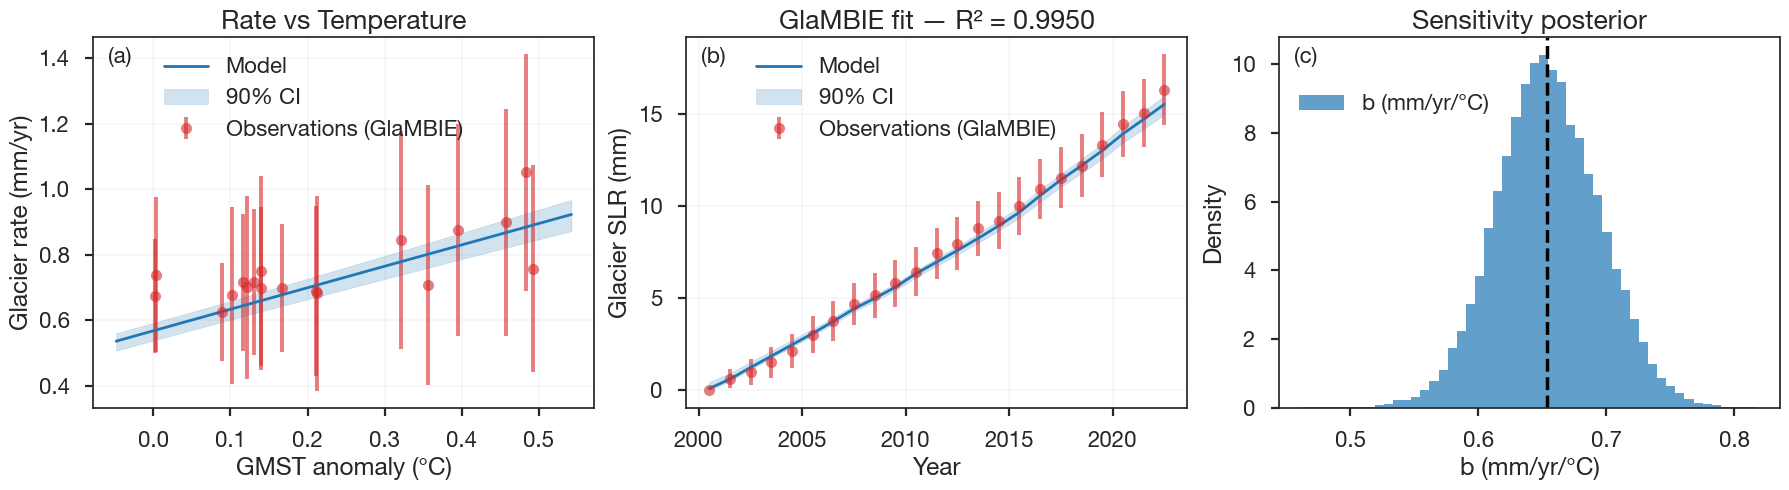

In [5]:
if REFIT:
    _tick_fs = plt.rcParams.get('xtick.labelsize', 12)
    _gc = 'tab:red'
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Rate vs T scatter
    ax = axes[0]
    from component_analysis import compute_component_rates
    rates = compute_component_rates(glac_year, glac_rebase, window=3) * M_TO_MM
    # Propagate cumulative uncertainty through the same centred-difference window
    _w = 3
    rate_sigma = np.full_like(rates, np.nan)
    for _i in range(_w, len(glac_rebase) - _w):
        _dt = glac_year[_i + _w] - glac_year[_i - _w]
        rate_sigma[_i] = np.sqrt(glac_sigma[_i + _w]**2 + glac_sigma[_i - _w]**2) / _dt * M_TO_MM
    yr_int = np.floor(temp_time_monthly).astype(int)
    T_ann = np.array([temp_monthly[yr_int == y].mean() for y in np.unique(yr_int)])
    T_ann_years = np.unique(yr_int) + 0.5
    T_at_glac = np.interp(glac_year, T_ann_years, T_ann)
    valid = np.isfinite(rates) & np.isfinite(T_at_glac)
    ax.errorbar(T_at_glac[valid], rates[valid], yerr=Z_90 * rate_sigma[valid],
                fmt='o', ms=8, alpha=0.6, color=_gc, label='Observations (GlaMBIE)')
    # Overlay linear model with 90% CI band from posterior draws
    T_grid = np.linspace(T_at_glac[valid].min() - 0.05, T_at_glac[valid].max() + 0.05, 100)
    _b_draws = result_lin.posterior_samples[:, 1] * M_TO_MM
    _c_draws = result_lin.posterior_samples[:, 2] * M_TO_MM
    _rate_ens = _b_draws[:, None] * T_grid[None, :] + _c_draws[:, None]
    _rate_p5, _rate_med, _rate_p95 = np.percentile(_rate_ens, [5, 50, 95], axis=0)
    ax.plot(T_grid, _rate_med, color='tab:blue', lw=2, label='Model')
    ax.fill_between(T_grid, _rate_p5, _rate_p95, color='tab:blue', alpha=0.2, label='90% CI')
    ax.set_xlabel('GMST anomaly (°C)')
    ax.set_ylabel('Glacier rate (mm/yr)')
    ax.set_title('Rate vs Temperature')
    ax.legend(fontsize=_tick_fs, loc='upper left', bbox_to_anchor=(0.1, 1))
    ax.grid(True, alpha=0.2)
    ax.text(0.03, 0.93, '(a)', transform=ax.transAxes, fontweight='bold', fontsize=_tick_fs)

    # Panel B: Model fit
    ax = axes[1]
    from component_analysis import model_ensemble_draws
    H_ens = model_ensemble_draws(result_lin, np.zeros_like(design_r['I2_obs']),
                                  design_r['I1_obs'], design_r['I0_obs'])
    p5, p50, p95 = np.percentile(H_ens * M_TO_MM, [5, 50, 95], axis=0)
    ax.errorbar(yrs_r, H_r * M_TO_MM, yerr=2 * sig_r * M_TO_MM,
                fmt='o', ms=8, color=_gc, alpha=0.6, label='Observations (GlaMBIE)')
    ax.plot(yrs_r, p50, color='tab:blue', lw=2, label='Model')
    ax.fill_between(yrs_r, p5, p95, color='tab:blue', alpha=0.2, label='90% CI')
    ax.set_ylabel('Glacier SLR (mm)')
    ax.set_xlabel('Year') 
    ax.set_title(f'GlaMBIE fit — R² = {result_lin.r2:.4f}')
    ax.legend(fontsize=_tick_fs, loc='upper left', bbox_to_anchor=(0.1, 1))
    ax.grid(True, alpha=0.2)
    ax.text(0.03, 0.93, '(b)', transform=ax.transAxes, fontweight='bold', fontsize=_tick_fs)

    # Panel C: Posteriors
    ax = axes[2]
    ax.hist(result_lin.posterior_samples[:, 1] * M_TO_MM, bins=50, density=True,
            alpha=0.7, color='tab:blue', label='b (mm/yr/°C)')
    ax.axvline(b_lin_med, color='k', ls='--', lw=2.5)
    ax.set_xlabel('b (mm/yr/°C)')
    ax.set_ylabel('Density')
    ax.set_title('Sensitivity posterior')
    ax.legend(fontsize=_tick_fs, loc='upper left', bbox_to_anchor=(0.0, 0.9))
    ax.text(0.03, 0.93, '(c)', transform=ax.transAxes, fontweight='bold', fontsize=_tick_fs)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_glacier_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping fit diagnostics')

## 4. Projections

In [6]:
# Constants needed by downstream cells regardless of REFIT
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
if REFIT:
    PROJ_YEARS = np.arange(1950, 2151, dtype=float)

# Load SSP temperatures (needed for plots downstream)
df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
offset = hist_bl - temp_bl

if REFIT:
    # ── Project under each SSP ──
    # Each SSP uses a distinct seed so that posterior draws are independent
    # across scenarios; only the temperature trajectory should differ.
    glacier_proj = {}
    for i, (ssp_name, h5_key) in enumerate(SSP_H5_MAP.items()):
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset

        t_mon = np.arange(combined['decimal_year'].min(),
                           combined['decimal_year'].max(), 1/12)
        T_mon = np.interp(t_mon, combined['decimal_year'].values,
                           combined['temperature'].values)
        T_full = np.concatenate([temp_monthly, T_mon[t_mon > temp_time_monthly[-1]]])
        t_full = np.concatenate([temp_time_monthly, t_mon[t_mon > temp_time_monthly[-1]]])

        proj = project_component_level_ensemble(
            posterior_samples=result_lin.posterior_samples,
            H0_samples=result_lin.H0_posterior,
            temperature_monthly=T_full,
            time_monthly=t_full,
            projection_times=PROJ_YEARS,
            baseline_year=BASELINE_YEAR,
            n_samples=N_SAMPLES,
            order=1,
            seed=400 + i,
        )
        proj['samples'] = apply_glacier_volume_cap(proj['samples'], V_GLACIER_TOTAL_M)
        proj['median'] = np.median(proj['samples'], axis=0)
        proj['p5'] = np.percentile(proj['samples'], 5, axis=0)
        proj['p95'] = np.percentile(proj['samples'], 95, axis=0)
        proj['p17'] = np.percentile(proj['samples'], 17, axis=0)
        proj['p83'] = np.percentile(proj['samples'], 83, axis=0)
        glacier_proj[ssp_name] = proj

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        n_capped = np.sum(proj['samples'][:, idx_2100] >= V_GLACIER_TOTAL_M)
        print(f'{ssp_name} at 2100: {proj["median"][idx_2100]*M_TO_MM:.0f} '
              f'[{proj["p5"][idx_2100]*M_TO_MM:.0f}, {proj["p95"][idx_2100]*M_TO_MM:.0f}] mm '
              f'({n_capped} capped)')

    # ── Save to HDF5 ──
    save_glacier(
        result_lin=result_lin,
        obs_years=glac_year,
        obs_H=glac_rebase,
        obs_sigma=glac_sigma,
        proj_dict=glacier_proj,
        v_glacier_total_m=V_GLACIER_TOTAL_M,
        extra_metadata={'r2': float(result_lin.r2)},
    )
else:
    # Already loaded in REFIT switch cell — just print summary
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = glacier_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = glacier_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = glacier_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

SSP1-2.6 at 2100: 107 [100, 112] mm (0 capped)
SSP2-4.5 at 2100: 128 [120, 136] mm (0 capped)
SSP3-7.0 at 2100: 148 [138, 158] mm (0 capped)
SSP5-8.5 at 2100: 167 [155, 179] mm (0 capped)


Saved glacier → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (459584 KB total)


/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:954: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


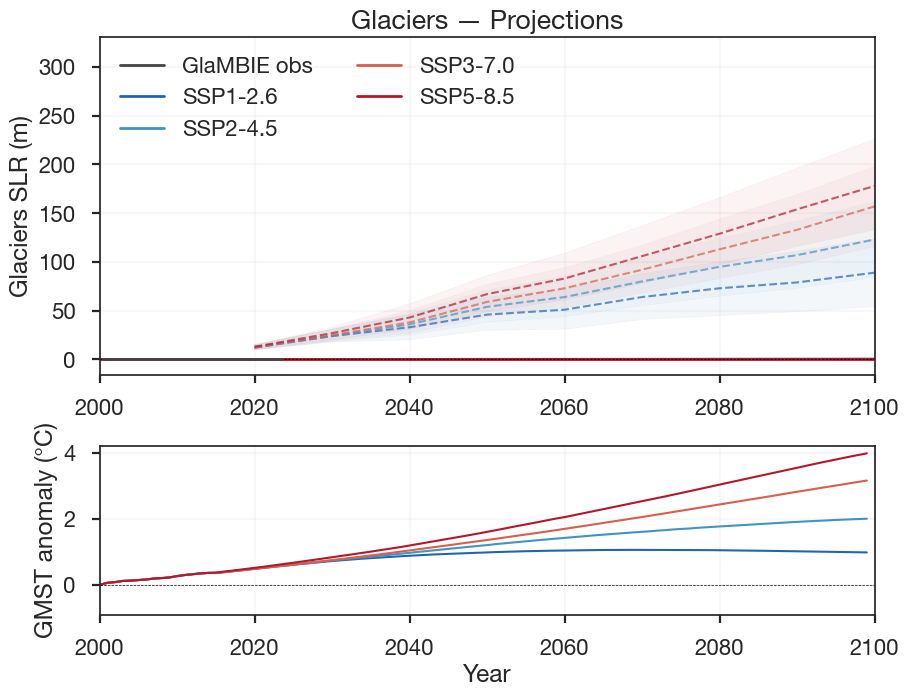

In [7]:
# Build temperature scenarios for lower panel
temp_scenarios = {}
for ssp_name, h5_key in SSP_H5_MAP.items():
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    ann = combined.groupby(combined['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp_name] = {'years': ann['decimal_year'].values,
                                 'temperature': ann['temperature'].values}

# Load IPCC glacier projections for comparison overlay
ipcc_glaciers = {}
for ssp in PROJ_SSPS:
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                        SSP_CODE[ssp], 'glaciers')
    if ipcc_comp is not None:
        ipcc_glaciers[ssp] = ipcc_comp

plot_component_projection_twopanel(
    comp_proj=glacier_proj, proj_years=PROJ_YEARS,
    component_name='Glaciers',
    temperature_scenarios=temp_scenarios,
    ssps=PROJ_SSPS,
    xlim=(2000,2100),
    obs_years=glac_year, obs_vals=glac_rebase, obs_sigma=glac_sigma,
    obs_label='GlaMBIE obs',
    ipcc_data=ipcc_glaciers, ipcc_key='IPCC AR6',
    save_path=f'{FIG_DIR}/component_glacier_twopanel.png',
)

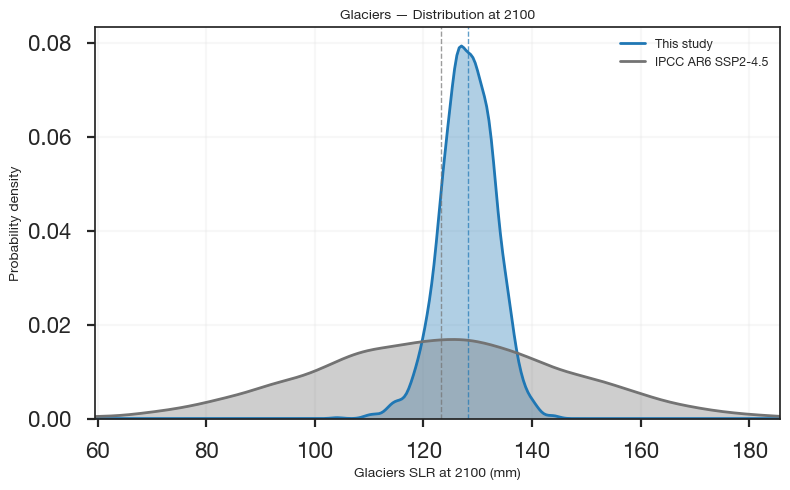

In [8]:
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'
rng_hist = np.random.default_rng(99)

our_samples = glacier_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

# IPCC — approximate the IPCC distribution as Gaussian from its 5th/95th
# quantiles.  This is a simplification: IPCC distributions can be mildly
# skewed, but the Gaussian approximation is adequate for visual comparison
# of central tendency and spread.
ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', SSP_CODE[HIST_SSP], 'glaciers')
sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if ipcc_data is not None:
    ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ex['years'] - 2100))
    ipcc_med = ex['q50'][yr_idx]
    ipcc_sig = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * Z_90)
    ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples)
    labels.append(f'IPCC AR6 {HIST_SSP}')
    colors.append('0.45')

plot_component_histogram(sample_sets, labels, colors, 'Glaciers', year=2100,
                          save_path=f'{FIG_DIR}/component_glacier_histogram_2100.png')

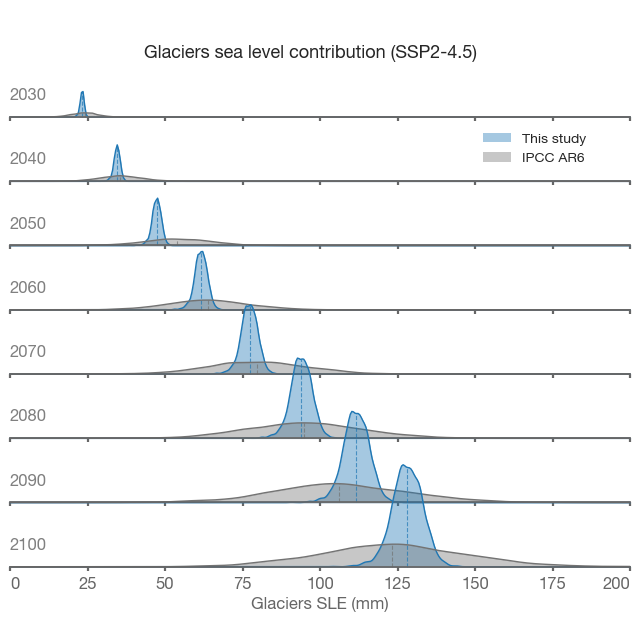

In [9]:
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    year_dict = {'This study': glacier_proj[RIDGE_SSP]['samples'][:, idx_yr] * M_TO_MM}
    if ipcc_data is not None:
        ex = ipcc_extract(ipcc_data)
        yr_idx = np.argmin(np.abs(ex['years'] - yr))
        if np.abs(ex['years'][yr_idx] - yr) < 5:
            ipcc_med_yr = ex['q50'][yr_idx]
            ipcc_sig_yr = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * Z_90)
            year_dict['IPCC AR6'] = rng_ridge.normal(ipcc_med_yr, ipcc_sig_yr, N_SAMPLES)
    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'Glaciers', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'IPCC AR6': '0.45'},
                      xlabel='Glaciers SLE (mm)',
                      title=f'Glaciers sea level contribution ({RIDGE_SSP})',
                      xlim=(0,200),
                      top=1.04, legend_bbox=(0.95, -0.03),
                      fontsize={'year': 12, 'title': 13, 'legend': 10, 'xlabel': 12, 'xtick': 12},
                      save_path=f'{FIG_DIR}/component_glacier_ridge.png')

## 5. IPCC Comparison & Hindcast

SSP1-2.6: b=-0.725 mm/yr/°C, c=1.591 mm/yr, R²=0.0810
SSP2-4.5: b=0.128 mm/yr/°C, c=1.179 mm/yr, R²=0.0747
SSP3-7.0: b=0.316 mm/yr/°C, c=1.223 mm/yr, R²=0.2799
SSP5-8.5: b=0.292 mm/yr/°C, c=1.429 mm/yr, R²=0.3545


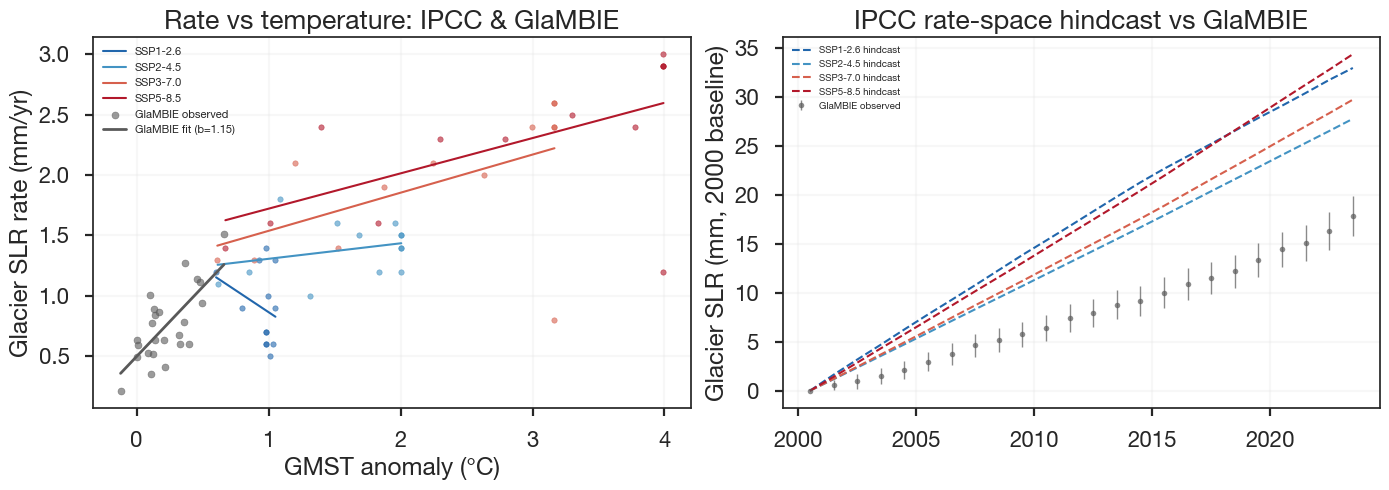

In [10]:
# ── IPCC sensitivity in rate space & hindcast ──
# Fit dH/dt = b·T + c to IPCC glacier median rates.
# Rate space avoids the I1/I0 collinearity that plagued the cumulative fit,
# while retaining the constant committed mass-loss rate c.

glacier_ipcc_fits = {}
# Store per-SSP combined temperature DataFrames for reuse in Panel A
_ssp_combined = {}
for ssp in PROJ_SSPS:
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                        SSP_CODE[ssp], 'glaciers')
    if ipcc_comp is None:
        continue
    ex = ipcc_extract(ipcc_comp)
    years_ipcc = ex['years']
    slc_mm = ex['q50']

    # Get GMST at IPCC years
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{SSP_H5_MAP[ssp]}')
    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined_ssp = pd.concat([hist_part, df_ssp]).sort_index()
    combined_ssp = combined_ssp[~combined_ssp.index.duplicated(keep='last')]
    combined_ssp['temperature'] = combined_ssp['temperature'] - offset
    _ssp_combined[ssp] = combined_ssp
    T_at_ipcc = np.interp(years_ipcc, combined_ssp['decimal_year'].values,
                           combined_ssp['temperature'].values)

    # Rate-space fit: dH/dt = b·T + c
    dt_ipcc = np.diff(years_ipcc)
    rate_ipcc = np.diff(slc_mm) / dt_ipcc  # mm/yr
    T_mid = 0.5 * (T_at_ipcc[:-1] + T_at_ipcc[1:])

    X_rate = np.column_stack([T_mid, np.ones(len(T_mid))])
    coeff, _, _, _ = np.linalg.lstsq(X_rate, rate_ipcc, rcond=None)
    coeff = coeff.ravel()
    rate_fit = X_rate @ coeff
    ss_res = np.sum((rate_ipcc - rate_fit)**2)
    ss_tot = np.sum((rate_ipcc - np.mean(rate_ipcc))**2)
    r2 = 1 - ss_res / ss_tot

    glacier_ipcc_fits[ssp] = {
        'b': float(coeff[0]), 'c': float(coeff[1]), 'r2': float(r2),
    }
    print(f'{ssp}: b={coeff[0]:.3f} mm/yr/°C, c={coeff[1]:.3f} mm/yr, R²={r2:.4f}')

# ── Hindcast: integrate rate = b·T + c using observed annual GMST ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Rate vs T (IPCC + fit line)
ax = axes[0]
for ssp, fit in glacier_ipcc_fits.items():
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                        SSP_CODE[ssp], 'glaciers')
    ex = ipcc_extract(ipcc_comp)
    dt_i = np.diff(ex['years'])
    rate_i = np.diff(ex['q50']) / dt_i
    # Use THIS SSP's temperature trajectory (not the last one from the loop)
    comb_ssp = _ssp_combined[ssp]
    T_i = np.interp(ex['years'], comb_ssp['decimal_year'].values,
                     comb_ssp['temperature'].values)
    T_mid_i = 0.5 * (T_i[:-1] + T_i[1:])
    color = SSP_COLORS.get(ssp, 'gray')
    ax.scatter(T_mid_i, rate_i, s=15, color=color, alpha=0.6)
    T_range = np.linspace(T_mid_i.min(), T_mid_i.max(), 50)
    ax.plot(T_range, fit['b'] * T_range + fit['c'], '-', color=color, lw=1.5, label=ssp)
# GlaMBIE observed rates
glac_rate_mm = glac_rate * M_TO_MM  # m/yr → mm/yr
T_at_glac = np.interp(glac_year, T_annual_years, T_annual)
ax.scatter(T_at_glac, glac_rate_mm, s=25, color='0.35', marker='o', zorder=5,
           alpha=0.6, label='GlaMBIE observed')

# GlaMBIE OLS trend
X_glam = np.column_stack([T_at_glac, np.ones(len(T_at_glac))])
c_glam, _, _, _ = np.linalg.lstsq(X_glam, glac_rate_mm, rcond=None)
c_glam = c_glam.ravel()
T_glam_range = np.linspace(T_at_glac.min(), T_at_glac.max(), 50)
ax.plot(T_glam_range, c_glam[0] * T_glam_range + c_glam[1], '-', color='0.35',
        lw=2, label=f'GlaMBIE fit (b={c_glam[0]:.2f})')

ax.set_xlabel('GMST anomaly (°C)')
ax.set_ylabel('Glacier SLR rate (mm/yr)')
ax.set_title('Rate vs temperature: IPCC & GlaMBIE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Panel B: Cumulative hindcast vs GlaMBIE
ax = axes[1]
ax.errorbar(glac_year, glac_rebase * M_TO_MM, yerr=2 * glac_sigma * M_TO_MM,
            fmt='o', ms=4, lw=1, color='0.35', alpha=0.7, label='GlaMBIE observed', zorder=5)

# Integrate rate = b·T(t) + c over GlaMBIE years, rebase to BASELINE_YEAR
T_obs_annual = np.interp(glac_year, T_annual_years, T_annual)
for ssp, fit in glacier_ipcc_fits.items():
    # Rate at each GlaMBIE year
    rate_hind = fit['b'] * T_obs_annual + fit['c']  # mm/yr
    # Cumulative via trapezoidal integration
    dt_gl = np.diff(glac_year)
    cumul = np.concatenate([[0], np.cumsum(0.5 * (rate_hind[:-1] + rate_hind[1:]) * dt_gl)])
    # Rebase to BASELINE_YEAR (2000)
    bl = np.argmin(np.abs(glac_year - BASELINE_YEAR))
    cumul -= cumul[bl]

    color = SSP_COLORS.get(ssp, 'gray')
    ax.plot(glac_year, cumul, '--', lw=1.5, color=color, label=f'{ssp} hindcast')

ax.set_ylabel('Glacier SLR (mm, 2000 baseline)')
ax.set_title('IPCC rate-space hindcast vs GlaMBIE')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ipcc_hindcast_glaciers.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Appendix: Sensitivity & Sundries

### Taper sensitivity
### Volume cap impact
### Model selection justification

In [11]:
F_MAX_VALUES = [1, 2, 3]
TAPER_REF = 2000

taper_results_glac = {}
for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(sig_r, yrs_r, TAPER_REF, f_max)
    res_q = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=design_r['I2_obs'], I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200 + f_max*100, **prior_kw)
    res_l = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_r['I2_obs']),
        I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300 + f_max*100, **prior_kw)
    taper_results_glac[f_max] = {'quad': res_q, 'linear': res_l}

    a_s = res_q.posterior_samples[:, 0] * M_TO_MM
    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    print(f'f_max={f_max}: a={np.median(a_s):.4f}, ΔBIC={bic_l - bic_q:+.1f}, '
          f'P(a>0)={np.mean(res_q.posterior_samples[:, 0] > 0)*100:.0f}%')

Bayesian level-space fit: n=23 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.514, b=0.826, c=0.605 mm/yr, σ_extra=0.19 mm


  0%|          | 0/6000 [00:00<?, ?it/s]

  1%|▏         | 77/6000 [00:00<00:07, 768.15it/s]

  3%|▎         | 154/6000 [00:00<00:07, 764.52it/s]

  4%|▍         | 233/6000 [00:00<00:07, 774.85it/s]

...

 96%|█████████▌| 5769/6000 [00:07<00:00, 783.41it/s]

 97%|█████████▋| 5848/6000 [00:07<00:00, 780.06it/s]

 99%|█████████▉| 5927/6000 [00:07<00:00, 775.12it/s]

100%|██████████| 6000/6000 [00:07<00:00, 785.84it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.028  ESS_bulk=178  ESS_tail=311
    alpha0: R-hat=1.013  ESS_bulk=185  ESS_tail=463
    trend: R-hat=1.010  ESS_bulk=139  ESS_tail=279
    log_sigma_extra: R-hat=1.050  ESS_bulk=73  ESS_tail=86
    H0: R-hat=1.012  ESS_bulk=177  ESS_tail=512
  WARNINGS:
  log_sigma_extra: bulk ESS = 73 < 100 — increase samples or walkers
  log_sigma_extra: tail ESS = 86 < 100 — tail estimates unreliable
  Posterior mean: a=0.044, b=0.658, c=0.568 mm/yr
  σ_extra: median=0.10 mm [0.00, 0.41]
  R² = 0.9952,  acceptance = 0.46
f_max=3: a=0.0097, ΔBIC=-106.0, P(a>0)=100%


In [12]:
# Show impact of volume cap at 2100 and 2150
for yr in [2100, 2150]:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    for ssp in PROJ_SSPS:
        uncapped = glacier_proj[ssp]['samples'][:, idx_yr]
        n_capped = np.sum(uncapped >= V_GLACIER_TOTAL_M)
        frac_capped = n_capped / N_SAMPLES * 100
        print(f'{ssp} at {yr}: {frac_capped:.1f}% of samples hit volume cap '
              f'({V_GLACIER_TOTAL_M*M_TO_MM:.0f} mm SLE)')

SSP1-2.6 at 2100: 0.0% of samples hit volume cap (320 mm SLE)
SSP2-4.5 at 2100: 0.0% of samples hit volume cap (320 mm SLE)
SSP3-7.0 at 2100: 0.0% of samples hit volume cap (320 mm SLE)
SSP5-8.5 at 2100: 0.0% of samples hit volume cap (320 mm SLE)
SSP1-2.6 at 2150: 0.0% of samples hit volume cap (320 mm SLE)
SSP2-4.5 at 2150: 0.0% of samples hit volume cap (320 mm SLE)
SSP3-7.0 at 2150: 0.0% of samples hit volume cap (320 mm SLE)
SSP5-8.5 at 2150: 0.0% of samples hit volume cap (320 mm SLE)
